# Module 4 · Bayesian inference

*Bayesian inference / partial pooling — when a slice is too thin to call, anchor it on history.*

In Module 3 (`/significance-check`) we drilled into a single thin slice and got an
honest but **frustrating** answer: *"we can't tell."* The Bing "Summit beats Cedar"
gap was a coin-flip — its confidence interval straddled zero.

This module offers a different move. Instead of throwing the thin slice away, we
**Bayesian inference**: we anchor the noisy estimate on an *informative
prior* built from the same partner's behaviour in other channels, update with a
conjugate normal, and report a **posterior**, `P(better)`, and **expected loss**.

The punchline you will watch happen: **the apparent Bing flip reverses once anchored
on history.** It was regression to the mean all along.

**The 4-beat loop**, same as every module:
1. **Framing** — recap the coin-flip, pose the Bayesian alternative.
2. **By hand** — thin-slice EPC, prior from history, conjugate update from first principles.
3. **Extract** — reproduce with `ni_core`'s reviewed primitives; assert they match.
4. **Validate** — a simulation that recovers a *known* truth: coverage and RMSE.

Then: *"…and `/bayesian-update` automates exactly this."*

In [3]:
import sys
sys.path.insert(0, "/home/am/projects/natural-intelligence/new_workshop/.claude/skills/_lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_core as C

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
RNG_SEED = 42

# One row per click-out (grain for EPC). `clicked` flags rows carrying a partner.
df = C.load_clickouts()
clicked = df[df["clicked"]].copy()

# Our two partners live in the "Business Checkings" segment.
seg = clicked[clicked["segment"] == "Business Checkings"].copy()
PARTNERS = ["Summit Direct Business", "Cedar Business Bank"]

print("click-out rows:", len(clicked))
print("Business Checkings click-outs:", len(seg))
print("channels present:", sorted(seg["channel"].unique()))
seg.groupby(["partner", "channel"]).size().unstack(fill_value=0).loc[PARTNERS]

click-out rows: 82184
Business Checkings click-outs: 8070
channels present: ['Bing', 'Google', 'Organic', 'Social']


channel,Bing,Google,Organic,Social
partner,,,,
Summit Direct Business,431,1029,469,212
Cedar Business Bank,838,2047,862,475


## 1 · Framing — the coin-flip we're rescuing

Recall the drill-down from Module 3. Inside the **Bing** channel, "Business Checkings":

| partner | Bing EPC | n click-outs |
|---|---|---|
| Summit Direct Business | ~10.48 | 431 |
| Cedar Business Bank | ~8.16 | 838 |

Raw ordering in Bing: **Summit > Cedar** — a gap of about **+2.3 EPC**. That looks
like a win for Summit, and it *contradicts* the overall picture (across all channels
Cedar earns more). Hence "the flip."

But `/significance-check` bootstrapped that gap and the 95% CI **straddled zero** —
roughly `[-2.4, +7.8]`. So the honest verdict was *coin-flip: we can't tell.*

The cell below re-derives that so the number is real, not remembered.

In [4]:
summit_bing = seg[(seg.partner == "Summit Direct Business") & (seg.channel == "Bing")]["revenue"].to_numpy(float)
cedar_bing  = seg[(seg.partner == "Cedar Business Bank")     & (seg.channel == "Bing")]["revenue"].to_numpy(float)

boot = C.bootstrap_mean_diff_ci(summit_bing, cedar_bing)   # seeded, reviewed primitive
diff, lo, hi = boot["diff"], boot["diff_lo"], boot["diff_hi"]

print(f"Bing Summit EPC = {summit_bing.mean():.2f}  (n={len(summit_bing)})")
print(f"Bing Cedar EPC  = {cedar_bing.mean():.2f}  (n={len(cedar_bing)})")
print(f"raw diff (Summit - Cedar) = {diff:+.2f} EPC")
print(f"bootstrap 95% CI          = [{lo:+.2f}, {hi:+.2f}]")
print("CI includes 0? ->", (lo < 0 < hi), "  => coin-flip: we can't call it on this slice alone")

# Sanity-check the headline numbers before we build on them.
assert abs(summit_bing.mean() - 10.48) < 0.1
assert abs(cedar_bing.mean()  -  8.16) < 0.1
assert len(summit_bing) == 431 and len(cedar_bing) == 838
assert abs(diff - 2.3) < 0.2 and lo < 0 < hi

Bing Summit EPC = 10.48  (n=431)
Bing Cedar EPC  = 8.16  (n=838)
raw diff (Summit - Cedar) = +2.32 EPC
bootstrap 95% CI          = [-2.34, +7.59]
CI includes 0? -> True   => coin-flip: we can't call it on this slice alone


**The Bayesian pivot.** A frequentist CI answers *"could this gap be noise?"* — and
here the answer is yes. But we are not starting from zero knowledge. Each partner has a
**track record in other channels**. If Summit typically earns ~8 and Cedar typically
earns ~10 everywhere else, then a lone noisy Bing slice showing Summit at 10.5 is
*exactly* the kind of lucky-high reading we should expect to **regress** back toward
its own history.

So instead of *"we can't tell,"* we ask: **given the past, what should we now believe?**

## 2 · By hand — thin slice, prior, and the conjugate update

Three ingredients, each computed from the data:

1. **Likelihood (the thin slice):** the Bing EPC and its variance-of-the-mean
   `se² = Var(x)/n`. This is what the slice *alone* says.
2. **Prior (history):** the same partner's EPC in **all other channels** — its
   `mean` and `se²`. This is what we believed *before* looking at Bing.
3. **Posterior:** the precision-weighted blend. Precisions (`1/variance`) add:

$$\frac{1}{\sigma^2_{\text{post}}} = \frac{1}{\sigma^2_{\text{prior}}} + \frac{1}{\sigma^2_{\text{data}}},
\qquad
\mu_{\text{post}} = \sigma^2_{\text{post}}\left(\frac{\mu_{\text{prior}}}{\sigma^2_{\text{prior}}} + \frac{\mu_{\text{data}}}{\sigma^2_{\text{data}}}\right)$$

One wrinkle we honour from Module 2: click-outs can be **clustered** within a visit,
which makes the slice *less* informative than its raw `n` suggests. We inflate the
slice's `se²` by the slice **design effect** (`deff`) before the update — exactly what
`ni_core` does. (Here the click grain is one row per visit, so `deff ≈ 1.0` and the
inflation is a no-op — but we wire it in so the method is honest when it isn't.)

In [6]:
def partner_pieces(partner, channel="Bing"):
    """Compute the thin-slice likelihood (in `channel`) and prior (other channels)."""
    p = seg[seg.partner == partner]
    slice_df = p[p.channel == channel]
    other    = p[p.channel != channel]

    # Likelihood: mean + se^2 of the thin slice, se^2 inflated by the slice deff.
    d_mean, d_se2, d_n = C.mean_and_se2(slice_df["revenue"].to_numpy(float))
    deff = C.design_effect(slice_df["revenue"].to_numpy(float),
                           slice_df["visit_iid"].to_numpy())["deff"]
    d_se2_infl = d_se2 * deff

    # Prior: same partner, every other channel.
    p_mean, p_se2, p_n = C.mean_and_se2(other["revenue"].to_numpy(float))

    return dict(partner=partner, d_mean=d_mean, d_se2=d_se2, d_n=d_n, deff=deff,
                d_se2_infl=d_se2_infl, p_mean=p_mean, p_se2=p_se2, p_n=p_n)


def update_by_hand(pieces):
    """Conjugate normal update from first principles (precision-weighted)."""
    prior_prec = 1.0 / pieces["p_se2"]
    data_prec  = 1.0 / pieces["d_se2_infl"]
    var_post   = 1.0 / (prior_prec + data_prec)
    mean_post  = var_post * (pieces["p_mean"] * prior_prec + pieces["d_mean"] * data_prec)
    se_post    = np.sqrt(var_post)
    return dict(mean=mean_post, var=var_post, se=se_post,
                lo=mean_post - 1.96 * se_post, hi=mean_post + 1.96 * se_post)


byhand = {}
for partner in PARTNERS:
    pc = partner_pieces(partner)
    post = update_by_hand(pc)
    byhand[partner] = dict(pieces=pc, post=post)
    print(f"--- {partner} ---")
    print(f"  thin slice (Bing): mean={pc['d_mean']:.2f}  se^2={pc['d_se2']:.3f}  "
          f"n={pc['d_n']}  deff={pc['deff']:.3f}")
    print(f"  prior (other ch.): mean={pc['p_mean']:.2f}  se^2={pc['p_se2']:.3f}  n={pc['p_n']}")
    print(f"  POSTERIOR:         mean={post['mean']:.2f}  95% CI=[{post['lo']:.2f}, {post['hi']:.2f}]")
    print()

--- Summit Direct Business ---
  thin slice (Bing): mean=10.48  se^2=5.046  n=431  deff=1.000
  prior (other ch.): mean=8.10  se^2=0.693  n=1710
  POSTERIOR:         mean=8.39  95% CI=[6.86, 9.92]

--- Cedar Business Bank ---
  thin slice (Bing): mean=8.16  se^2=1.592  n=838  deff=1.000
  prior (other ch.): mean=9.97  se^2=4.370  n=3384
  POSTERIOR:         mean=8.64  95% CI=[6.53, 10.76]



In [7]:
# The reversal, stated plainly.
sm = byhand["Summit Direct Business"]
cd = byhand["Cedar Business Bank"]

print("RAW Bing ordering :  Summit %.2f  >  Cedar %.2f   (gap %+.2f)"
      % (sm["pieces"]["d_mean"], cd["pieces"]["d_mean"],
         sm["pieces"]["d_mean"] - cd["pieces"]["d_mean"]))
print("POSTERIOR ordering:  Cedar  %.2f  >  Summit %.2f   (gap %+.2f)"
      % (cd["post"]["mean"], sm["post"]["mean"],
         cd["post"]["mean"] - sm["post"]["mean"]))
print()
print("=> Once anchored on history, the flip REVERSES. Cedar is back on top.")

# Assert the verified targets (tolerance ~0.1).
assert abs(sm["post"]["mean"] - 8.39) < 0.1, sm["post"]["mean"]
assert abs(cd["post"]["mean"] - 8.64) < 0.1, cd["post"]["mean"]
assert abs(sm["post"]["lo"] - 6.86) < 0.1 and abs(sm["post"]["hi"] - 9.92) < 0.1
assert abs(cd["post"]["lo"] - 6.53) < 0.1 and abs(cd["post"]["hi"] - 10.76) < 0.1
assert cd["post"]["mean"] > sm["post"]["mean"], "posterior ordering must reverse"
print("\nby-hand posteriors match the verified targets.")

RAW Bing ordering :  Summit 10.48  >  Cedar 8.16   (gap +2.32)
POSTERIOR ordering:  Cedar  8.64  >  Summit 8.39   (gap +0.25)

=> Once anchored on history, the flip REVERSES. Cedar is back on top.

by-hand posteriors match the verified targets.


### Why did the ordering flip? Shrinkage / regression to the mean

Look at what the update *did* to each partner:

- **Summit** walked into Bing with a low history (~8.1) but posted a lucky-high Bing
  reading (~10.5). The posterior drags it **down** toward its own past → ~8.4.
- **Cedar** walked in with a high history (~10.0) but posted a low Bing reading (~8.2).
  The posterior pulls it **up** toward its past → ~8.6.

Both estimates are **shrunk toward their priors**, and the amount of shrinkage is set by
*how thin the slice is*: the noisier the likelihood, the harder it is pulled back. That
is **regression to the mean** made quantitative. An extreme reading from a small sample
is *evidence*, but weak evidence — so we don't let it fully override a well-established
track record.

The raw Bing gap wasn't a signal that Summit had suddenly become the better partner in
Bing. It was Summit getting a lucky draw and Cedar an unlucky one, in a slice too thin to
separate skill from luck.

### The same idea in A/B-testing language: CUPED

If you have run experiments, you have met this move under a different name. **CUPED**
(*Controlled-experiment Using Pre-Existing Data*) reduces the variance of a treatment
effect by **regressing out a pre-period covariate** — typically each unit's *own*
behaviour before the test. Users who were already high spenders are expected to be high
spenders during the test, so you subtract that expectation and only measure the
*surprise*.

The parallel is exact:

| here (partial pooling) | CUPED (A/B testing) |
|---|---|
| prior = partner's history in other channels | covariate = unit's pre-period metric |
| posterior anchors the thin slice on that prior | adjusted metric removes pre-period variance |
| shrinks noisy estimate toward what history predicts | narrows the CI **at a fixed sample size** |

Both buy **precision without collecting more data**, by using information you already
have. The catch is identical too, and we return to it at the close: it only helps if the
past is representative of the present.

## 3 · Extract — reproduce with the reviewed `ni_core` primitives

The by-hand version taught the mechanism. In production the arithmetic lives in fixed,
reviewed Python so Claude never plays calculator. We now reproduce every number with
`ni_core` and **assert** it matches the by-hand result to floating-point tolerance:

- `C.posterior_from_prior(...)` — the conjugate update,
- `C.p_better(...)` — `P(θ_Summit > θ_Cedar)`,
- `C.expected_loss_choosing(...)` — expected regret of each choice.

In [5]:
lib = {}
for partner in PARTNERS:
    pc = byhand[partner]["pieces"]
    post = C.posterior_from_prior(pc["p_mean"], pc["p_se2"], pc["d_mean"], pc["d_se2_infl"])
    lib[partner] = post
    hand = byhand[partner]["post"]
    # by-hand vs library agree to ~1e-9
    assert abs(post["mean"] - hand["mean"]) < 1e-9
    assert abs(post["lo"]   - hand["lo"])   < 1e-9
    assert abs(post["hi"]   - hand["hi"])   < 1e-9
    print(f"{partner:24s} posterior {post['mean']:.2f}  [{post['lo']:.2f}, {post['hi']:.2f}]  "
          f"(matches by-hand)")

print("\nAll ni_core posteriors match the by-hand update.")

Summit Direct Business   posterior 8.39  [6.86, 9.92]  (matches by-hand)
Cedar Business Bank      posterior 8.64  [6.53, 10.76]  (matches by-hand)

All ni_core posteriors match the by-hand update.


In [6]:
sm_post, cd_post = lib["Summit Direct Business"], lib["Cedar Business Bank"]

p_summit_better = C.p_better(sm_post["mean"], sm_post["var"], cd_post["mean"], cd_post["var"])
p_cedar_better  = 1.0 - p_summit_better
loss = C.expected_loss_choosing(sm_post["mean"], sm_post["var"], cd_post["mean"], cd_post["var"])

print(f"P(Summit > Cedar) = {p_summit_better:.1%}")
print(f"P(Cedar > Summit) = {p_cedar_better:.1%}")
print()
print(f"expected loss if we choose Summit = {loss['choose_a']:.3f} EPC")
print(f"expected loss if we choose Cedar  = {loss['choose_b']:.3f} EPC")
print()
lower = "Cedar" if loss["choose_b"] < loss["choose_a"] else "Summit"
print(f"=> Lower expected regret: choose {lower}.")

assert abs(p_summit_better - 0.425) < 0.02, p_summit_better
assert p_summit_better < 0.5, "posterior should favour Cedar"
assert loss["choose_b"] < loss["choose_a"], "choosing Cedar should carry less regret"

P(Summit > Cedar) = 42.5%
P(Cedar > Summit) = 57.5%

expected loss if we choose Summit = 0.667 EPC
expected loss if we choose Cedar  = 0.415 EPC

=> Lower expected regret: choose Cedar.


**Reading `P(Summit > Cedar) ≈ 43%`.** This is not a p-value; it is a direct,
decision-ready probability: *after* folding in history, there's about a 43% chance
Summit is truly the better partner in Bing — so about **57% for Cedar**. Not a landslide
(the slices really are thin), but it points the *opposite* way from the raw +2.3 gap, and
it comes with an **expected-loss** number that a budget owner can act on: picking Cedar
carries the smaller expected regret.

### A picture of the shrinkage

For each partner, three marks on one line: the **thin-slice** estimate (where Bing alone
points), the **prior** (history), and the **posterior** with its 95% CI (where we land).
The posterior sits *between* slice and prior — pulled toward history by an amount set by
how noisy the slice is. Watch the two posteriors cross over relative to the raw slices:
that crossover **is** the flip reversing.

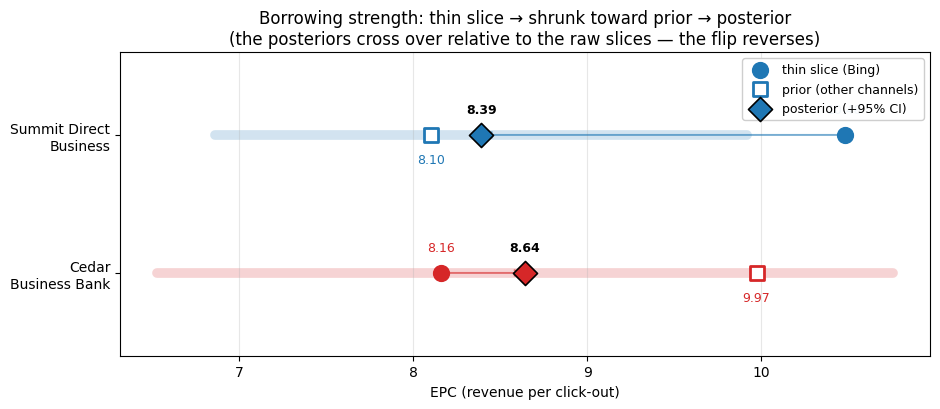

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
colors = {"Summit Direct Business": "#1f77b4", "Cedar Business Bank": "#d62728"}
y_of = {"Summit Direct Business": 1.0, "Cedar Business Bank": 0.0}

for partner in PARTNERS:
    pc = byhand[partner]["pieces"]
    post = lib[partner]
    y = y_of[partner]
    c = colors[partner]

    # posterior CI as a horizontal band
    ax.plot([post["lo"], post["hi"]], [y, y], color=c, lw=7, alpha=0.20,
            solid_capstyle="round", zorder=1)
    # the three point estimates
    ax.scatter(pc["d_mean"], y, marker="o", s=130, color=c, zorder=3,
               label="thin slice (Bing)" if partner == PARTNERS[0] else None)
    ax.scatter(pc["p_mean"], y, marker="s", s=110, facecolors="white",
               edgecolors=c, linewidths=2, zorder=3,
               label="prior (other channels)" if partner == PARTNERS[0] else None)
    ax.scatter(post["mean"], y, marker="D", s=150, color=c, edgecolors="black",
               linewidths=1.2, zorder=4,
               label="posterior (+95% CI)" if partner == PARTNERS[0] else None)
    # shrinkage arrow: slice -> posterior
    ax.annotate("", xy=(post["mean"], y), xytext=(pc["d_mean"], y),
                arrowprops=dict(arrowstyle="->", color=c, lw=1.4, alpha=0.6,
                                connectionstyle="arc3,rad=0.0"), zorder=2)
    ax.text(pc["d_mean"], y + 0.16, f"{pc['d_mean']:.2f}", ha="center", color=c, fontsize=9)
    ax.text(pc["p_mean"], y - 0.20, f"{pc['p_mean']:.2f}", ha="center", color=c, fontsize=9)
    ax.text(post["mean"], y + 0.16, f"{post['mean']:.2f}", ha="center",
            color="black", fontsize=9, fontweight="bold")

ax.set_yticks([y_of[p] for p in PARTNERS])
ax.set_yticklabels([p.replace(" Business", "\nBusiness") for p in PARTNERS])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("EPC (revenue per click-out)")
ax.set_title("Borrowing strength: thin slice → shrunk toward prior → posterior\n"
             "(the posteriors cross over relative to the raw slices — the flip reverses)")
ax.legend(loc="upper right", fontsize=9, framealpha=0.95)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 4 · Validate — does borrowing strength actually recover truth? 💰

Everything above is only worth trusting if the method **recovers a known answer** when we
control the truth. So we run three seeded Monte-Carlo checks:

**A. Coverage.** Draw many true EPCs from a prior, generate a thin noisy slice for each,
form the posterior, and ask: does the posterior 95% CI cover the *true* value about **95%**
of the time? (A method whose intervals lie are worthless.)

**B. RMSE — does shrinkage actually help?** For the same draws, compare the **raw slice**
estimate against the **posterior** estimate, both versus truth. If borrowing strength is
real, the posterior's RMSE is **lower** — precision bought for free.

**C. `P(better)` calibration.** On a simple two-arm simulation, bucket the predicted
`P(A>B)` and check that when we say "70%," A really wins about 70% of the time.

Seed fixed at `default_rng(42)`; the whole thing runs in a second or two.

In [8]:
rng = np.random.default_rng(42)

# ---- A & B: coverage + RMSE of posterior vs raw slice ----------------------
N_SIM      = 40_000
PRIOR_MEAN = 9.0      # what history says on average (EPC-scale)
PRIOR_SD   = 1.3      # spread of true partner EPCs around that
SLICE_SD   = 2.0      # noise in a thin-slice mean (small-n se)

# The prior we (correctly) hold going in:
prior_se2 = PRIOR_SD ** 2
data_se2  = SLICE_SD ** 2

theta_true = rng.normal(PRIOR_MEAN, PRIOR_SD, N_SIM)          # unknown truth
slice_hat  = rng.normal(theta_true, SLICE_SD, N_SIM)          # thin, noisy slice

# Posterior for every simulated slice (vectorised conjugate update).
var_post  = 1.0 / (1.0 / prior_se2 + 1.0 / data_se2)
mean_post = var_post * (PRIOR_MEAN / prior_se2 + slice_hat / data_se2)
se_post   = np.sqrt(var_post)
lo, hi    = mean_post - 1.96 * se_post, mean_post + 1.96 * se_post

coverage = np.mean((lo <= theta_true) & (theta_true <= hi))
rmse_raw  = np.sqrt(np.mean((slice_hat  - theta_true) ** 2))
rmse_post = np.sqrt(np.mean((mean_post - theta_true) ** 2))
rmse_drop = 100 * (1 - rmse_post / rmse_raw)

print(f"[A] posterior 95% CI coverage of truth : {coverage:.1%}   (target ~95%)")
print(f"[B] RMSE raw thin slice   vs truth      : {rmse_raw:.3f}")
print(f"[B] RMSE posterior        vs truth      : {rmse_post:.3f}")
print(f"[B] RMSE reduction from borrowing       : {rmse_drop:.1f}%  (lower is better)")

assert 0.93 <= coverage <= 0.97, coverage
assert rmse_post < rmse_raw, "posterior must beat the raw slice"

[A] posterior 95% CI coverage of truth : 94.9%   (target ~95%)
[B] RMSE raw thin slice   vs truth      : 2.002
[B] RMSE posterior        vs truth      : 1.098
[B] RMSE reduction from borrowing       : 45.2%  (lower is better)


In [9]:
# ---- C: is P(better) calibrated? -------------------------------------------
N_PAIRS  = 60_000
theta_a  = rng.normal(PRIOR_MEAN, PRIOR_SD, N_PAIRS)
theta_b  = rng.normal(PRIOR_MEAN, PRIOR_SD, N_PAIRS)
hat_a    = rng.normal(theta_a, SLICE_SD, N_PAIRS)
hat_b    = rng.normal(theta_b, SLICE_SD, N_PAIRS)

post_a = var_post * (PRIOR_MEAN / prior_se2 + hat_a / data_se2)
post_b = var_post * (PRIOR_MEAN / prior_se2 + hat_b / data_se2)
pred   = stats.norm.cdf((post_a - post_b) / np.sqrt(2 * var_post))   # P(A>B) predicted
actual_a_wins = (theta_a > theta_b).astype(float)

bins = np.linspace(0, 1, 11)
idx  = np.clip(np.digitize(pred, bins) - 1, 0, 9)
print("predicted P(A>B)   empirical A-wins   n")
cal_pred, cal_emp = [], []
for b in range(10):
    m = idx == b
    if m.sum() == 0:
        continue
    pm, em = pred[m].mean(), actual_a_wins[m].mean()
    cal_pred.append(pm); cal_emp.append(em)
    print(f"   {pm:5.2f}              {em:5.2f}        {m.sum():6d}")

cal_pred, cal_emp = np.array(cal_pred), np.array(cal_emp)
max_gap = np.max(np.abs(cal_pred - cal_emp))
print(f"\nmax |predicted - empirical| across buckets = {max_gap:.3f}  (well-calibrated if small)")
assert max_gap < 0.05, max_gap

predicted P(A>B)   empirical A-wins   n
    0.07               0.07          1471
    0.16               0.16          4429
    0.25               0.24          6785
    0.35               0.35          8276
    0.45               0.44          8974
    0.55               0.55          9189
    0.65               0.65          8349
    0.75               0.75          6670
    0.85               0.85          4442
    0.93               0.93          1415

max |predicted - empirical| across buckets = 0.009  (well-calibrated if small)


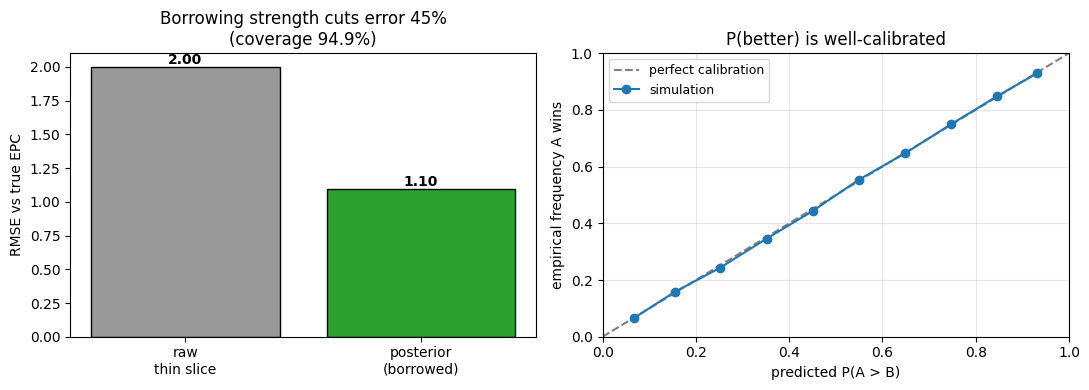

VALIDATION
  coverage of 95% CI : 94.9%  (nominal 95%)
  RMSE reduction     : 45.2%  (posterior beats raw slice)
  P(better) max gap  : 0.009  (calibrated)
  => borrowing strength recovers truth AND is more precise than the thin slice.


In [10]:
# Two small pictures: RMSE bars, and the P(better) calibration line.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(["raw\nthin slice", "posterior\n(borrowed)"], [rmse_raw, rmse_post],
        color=["#999999", "#2ca02c"], edgecolor="black")
ax1.set_ylabel("RMSE vs true EPC")
ax1.set_title(f"Borrowing strength cuts error {rmse_drop:.0f}%\n(coverage {coverage:.1%})")
for i, v in enumerate([rmse_raw, rmse_post]):
    ax1.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")

ax2.plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
ax2.plot(cal_pred, cal_emp, "o-", color="#1f77b4", label="simulation")
ax2.set_xlabel("predicted P(A > B)")
ax2.set_ylabel("empirical frequency A wins")
ax2.set_title("P(better) is well-calibrated")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("VALIDATION")
print(f"  coverage of 95% CI : {coverage:.1%}  (nominal 95%)")
print(f"  RMSE reduction     : {rmse_drop:.1f}%  (posterior beats raw slice)")
print(f"  P(better) max gap  : {max_gap:.3f}  (calibrated)")
print("  => borrowing strength recovers truth AND is more precise than the thin slice.")

## 5 · Close — `/bayesian-update` automates exactly this

What we did by hand — thin-slice likelihood, a prior from history, a conjugate update,
then `P(better)` and expected loss — is precisely what the **`/bayesian-update`** skill
runs for you: same reviewed `ni_core` primitives, same seeded arithmetic, byte-identical
output every time.

### What we learned
- A thin slice that a significance test calls a **coin-flip** is not a dead end — it's an
  invitation to bring in **prior evidence**.
- Anchoring the noisy Bing slice on each partner's **history** reversed the apparent flip:
  posterior **Cedar ≈ 8.64 > Summit ≈ 8.39**, `P(Summit > Cedar) ≈ 43%`. The raw +2.3 gap
  was **regression to the mean**.
- The simulation confirmed the method is **honest** (≈95% coverage) and **helpful**
  (lower RMSE than the raw slice) — precision bought from data we already had, the same
  bargain **CUPED** strikes in A/B testing.

### The honest caveat — carry it forward
> **A prior only helps if the past is representative of the present.** Partial pooling
> assumes **stationarity**: that a partner's other-channel history is a fair guide to its
> Bing behaviour *now*. If a **regime break** has occurred — a new campaign, a pricing
> change, seasonality, a partner that genuinely behaves differently in Bing — then the
> prior doesn't rescue the estimate, it **biases** it, dragging you toward a past that no
> longer holds.

So before you lean on history, check that history still applies. If you suspect the ground
has shifted, validate with **`/trend-check`** (Module 5) first — *then* borrow strength.
Used on stationary data it is one of the sharpest tools you have; used across a regime
break it quietly misleads. Know which world you're in.